# All_Beauty EDA

Amazon Reviews 2018 **All_Beauty** raw / processed 탐색용 노트북.

- Raw: `data/raw/*.json.gz` (줄마다 JSON)
- Processed: `data/processed/*.parquet` (`scripts.prepare_splits` 이후)

Working directory는 **레포 루트** 또는 `notebooks/` 둘 다 동작하도록 `ROOT`를 잡습니다.

In [9]:
from __future__ import annotations

import gzip
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# notebooks/ 에서 실행해도, 루트에서 실행해도 OK
cwd = Path.cwd()
ROOT = cwd if (cwd / "data").exists() else cwd.parent
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

print("ROOT:", ROOT)
print("raw exists:", (RAW / "All_Beauty.json.gz").exists())
print("processed exists:", (PROCESSED / "interactions_train.parquet").exists())

ROOT: c:\Users\user\Desktop\Git Repository\why-this-product
raw exists: True
processed exists: True


## 1. Raw peek (gzip JSONL)

한 줄 = 리뷰 또는 상품 메타 객체 하나.

In [10]:
def peek_json_gz(path: Path, n: int = 3) -> list[dict]:
    rows: list[dict] = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            line = line.strip()
            line = (
                line.replace(": NaN", ": null")
                .replace(": Infinity", ": null")
                .replace(":-Infinity", ": null")
            )
            rows.append(json.loads(line))
    return rows


reviews_sample = peek_json_gz(RAW / "All_Beauty.json.gz", n=2)
meta_sample = peek_json_gz(RAW / "meta_All_Beauty.json.gz", n=2)

print("review keys:", list(reviews_sample[0].keys()))
display(pd.DataFrame(reviews_sample))
print("meta keys:", list(meta_sample[0].keys()))
display(pd.DataFrame([{k: str(v)[:80] for k, v in r.items()} for r in meta_sample]))

review keys: ['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime']


,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime
0,1.0,True,"02 19, 2015",A1V6B6TNIC10QE,0143026860,theodore j bigham,great,One Star,1424304000
1,4.0,True,"12 18, 2014",A2F5GHSXFQ0W6J,0143026860,Mary K. Byke,My husband wanted to reading about the Negro ...,... to reading about the Negro Baseball and th...,1418860800


meta keys: ['category', 'tech1', 'description', 'fit', 'title', 'also_buy', 'tech2', 'brand', 'feature', 'rank', 'also_view', 'details', 'main_cat', 'similar_item', 'date', 'price', 'asin', 'imageURL', 'imageURLHighRes']


,category,tech1,description,fit,title,also_buy,tech2,brand,feature,rank,also_view,details,main_cat,similar_item,date,price,asin,imageURL,imageURLHighRes
0,[],,"[""Loud 'N Clear Personal Sound Amplifier allow...",,Loud 'N Clear&trade; Personal Sound Amplifier,[],,idea village,[],"2,938,573 in Beauty & Personal Care (",[],{'ASIN: ': '6546546450'},All Beauty,,,,6546546450,[],[]
1,[],,['No7 Lift & Luminate Triple Action Serum 50ml...,,No7 Lift &amp; Luminate Triple Action Serum 50...,"['B01E7LCSL6', 'B008X5RVME']",,,[],"872,854 in Beauty & Personal Care (",[],"{'Shipping Weight:': '0.3 ounces (', 'ASIN: ':...",All Beauty,"class=""a-bordered a-horizontal-stripes a-spa...",,$44.99,7178680776,[],[]


## 2. Processed tables

`prepare_splits` 결과. 없으면 위 셀에서 raw만 보고, 아래는 스킵.

In [11]:
train_path = PROCESSED / "interactions_train.parquet"
valid_path = PROCESSED / "interactions_valid.parquet"
test_path = PROCESSED / "interactions_test.parquet"
items_path = PROCESSED / "items.parquet"

assert train_path.exists(), "Run: python -m scripts.prepare_splits"

train = pd.read_parquet(train_path)
valid = pd.read_parquet(valid_path)
test = pd.read_parquet(test_path)
items = pd.read_parquet(items_path)

print("train/valid/test:", len(train), len(valid), len(test))
print("items:", len(items))
print("train columns:", list(train.columns))
print("items columns:", list(items.columns))
display(train.head())
display(items.head())

train/valid/test: 285664 35708 35709
items: 32488
train columns: ['user_id', 'item_id', 'rating', 'timestamp', 'review_text']
items columns: ['item_id', 'title', 'brand', 'category', 'description', 'price', 'doc_text']


,user_id,item_id,rating,timestamp,review_text
0,A1U7T7UCCV3SBN,B000050B62,5.0,972777600,"Very good shaver, I have always purchased Nore..."
1,A3RVIXD86WUT1E,B000050FDP,5.0,973987200,Talk about a smooth shave. The blades are clo...
2,A2T6BSYG4QUA0W,B000050B69,5.0,974764800,"I've had a beard for, let's see, 20 years now,..."
3,A131YSUOCKTSXK,B000050B60,5.0,975283200,I got this for my fiance. he has the softest f...
4,A1KU904SBOHNNS,B000050B69,5.0,975369600,"Where I work , a certain airline, moustaches a..."


,item_id,title,brand,category,description,price,doc_text
0,6546546450,Loud 'N Clear&trade; Personal Sound Amplifier,idea village,All Beauty,Loud 'N Clear Personal Sound Amplifier allows ...,NaN,Loud 'N Clear&trade; Personal Sound Amplifier....
1,7178680776,No7 Lift &amp; Luminate Triple Action Serum 50...,NaN,All Beauty,No7 Lift & Luminate Triple Action Serum 50ml b...,44.99,No7 Lift &amp; Luminate Triple Action Serum 50...
2,7250468162,No7 Stay Perfect Foundation Cool Vanilla by No7,No7,All Beauty,No7 Stay Perfect Foundation now stays perfect ...,28.76,No7 Stay Perfect Foundation Cool Vanilla by No...
3,7367905066,Wella Koleston Perfect Hair Colour 44/44 Mediu...,NaN,All Beauty,NaN,NaN,Wella Koleston Perfect Hair Colour 44/44 Mediu...
4,7414204790,Lacto Calamine Skin Balance Oil control 120 ml...,Pirmal Healthcare,All Beauty,Lacto Calamine Skin Balance Daily Nourishing L...,12.15,Lacto Calamine Skin Balance Oil control 120 ml...


## 3. Basic distributions

In [12]:
all_inter = pd.concat([train, valid, test], ignore_index=True)

print("unique users:", all_inter["user_id"].nunique())
print("unique items:", all_inter["item_id"].nunique())
print("rating value counts:")
display(all_inter["rating"].value_counts().sort_index())

user_counts = all_inter.groupby("user_id").size()
item_counts = all_inter.groupby("item_id").size()
print("interactions per user — describe")
display(user_counts.describe())
print("interactions per item — describe")
display(item_counts.describe())

unique users: 319335
unique items: 32486
rating value counts:


rating
1.0     38486
2.0     19854
3.0     28809
4.0     50952
5.0    218980
Name: count, dtype: int64

interactions per user — describe


count    319335.000000
mean          1.118202
std           0.441716
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          25.000000
dtype: float64

interactions per item — describe


count    32486.000000
mean        10.991843
std         91.519468
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       8667.000000
dtype: float64

train ts range: 972777600 ~ 1492732800
valid ts range: 1492732800 ~ 1510617600
test  ts range: 1510617600 ~ 1538438400
train max <= valid min: True
valid max <= test min: True


<Axes: title={'center': 'Interactions per month'}, xlabel='timestamp'>

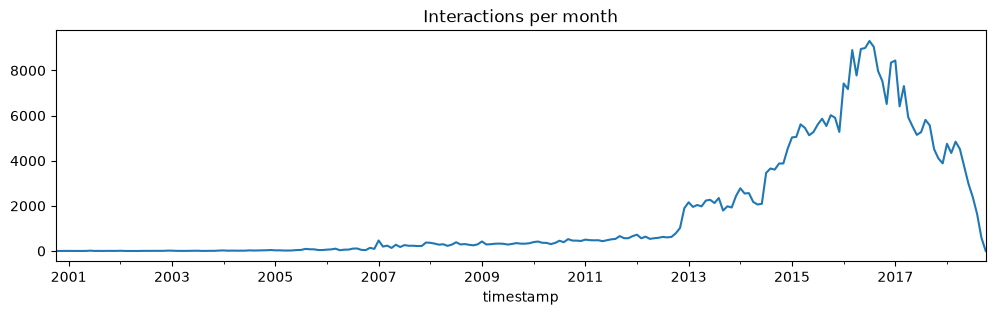

In [7]:
# Temporal split sanity: max(train ts) <= min(valid ts) <= ...
print("train ts range:", train["timestamp"].min(), "~", train["timestamp"].max())
print("valid ts range:", valid["timestamp"].min(), "~", valid["timestamp"].max())
print("test  ts range:", test["timestamp"].min(), "~", test["timestamp"].max())
print("train max <= valid min:", train["timestamp"].max() <= valid["timestamp"].min())
print("valid max <= test min:", valid["timestamp"].max() <= test["timestamp"].min())

ts = pd.to_datetime(all_inter["timestamp"], unit="s")
monthly = ts.dt.to_period("M").value_counts().sort_index()
monthly.plot(figsize=(12, 3), title="Interactions per month")

## 4. Item text / popularity peek

In [13]:
print("doc_text null/empty:", (items["doc_text"].fillna("").str.len() == 0).sum())
display(items[["item_id", "title", "brand", "doc_text"]].head(10))

top_items = (
    train["item_id"].value_counts().head(15).rename("train_count").reset_index()
)
top_items = top_items.merge(
    items[["item_id", "title", "brand"]],
    left_on="item_id",
    right_on="item_id",
    how="left",
)
display(top_items)

doc_text null/empty: 0


,item_id,title,brand,doc_text
0,6546546450,Loud 'N Clear&trade; Personal Sound Amplifier,idea village,Loud 'N Clear&trade; Personal Sound Amplifier....
1,7178680776,No7 Lift &amp; Luminate Triple Action Serum 50...,NaN,No7 Lift &amp; Luminate Triple Action Serum 50...
2,7250468162,No7 Stay Perfect Foundation Cool Vanilla by No7,No7,No7 Stay Perfect Foundation Cool Vanilla by No...
3,7367905066,Wella Koleston Perfect Hair Colour 44/44 Mediu...,NaN,Wella Koleston Perfect Hair Colour 44/44 Mediu...
4,7414204790,Lacto Calamine Skin Balance Oil control 120 ml...,Pirmal Healthcare,Lacto Calamine Skin Balance Oil control 120 ml...
5,7535842801,Mary Kay Satin Hands Hand Cream Travel MINI Si...,Mary Kay,Mary Kay Satin Hands Hand Cream Travel MINI Si...
6,7538626107,Unique Custom Cast Iron Liner Shader Tattoo Ma...,NaN,Unique Custom Cast Iron Liner Shader Tattoo Ma...
7,8279996397,Imagen Bendita Por Su Santidad Our Lady of Cha...,Chango,Imagen Bendita Por Su Santidad Our Lady of Cha...
8,8637910351,Mali princ,Srpska knjizevna zadruga,Mali princ. Srpska knjizevna zadruga. Novi pre...
9,8867326759,Moleskine Payne's Grey Card Wallet (Moleskine ...,Sunatoria,Moleskine Payne's Grey Card Wallet (Moleskine ...


,item_id,train_count,title,brand
0,B000FOI48G,8467,Waterpik Ultra Water Flosser,Waterpik
1,B000GLRREU,8167,Waterpik Ultra Water Flosser,Waterpik
2,B001QY8QXM,3637,Astra Platinum Double Edge Safety Razor Blades...,Astra
3,B0067F28ZW,1819,Eyelash Growth Serum - 100% Natural Eyelash Ey...,Fiery Youth
4,B006IB5T4W,1784,"Aquaphor Healing Ointment,Advanced Therapy Ski...",Aquaphor
5,B00005JS5C,1758,Panasonic Bikini Shaper and Trimmer for Women ...,Panasonic
6,B01DKQAXC0,1677,Bali Secrets Natural Deodorant - Organic &amp;...,NaN
7,B00VF344X0,1587,Italia Deluxe Ultra Fine Lip Liner set (Pack O...,Italia-Deluxe
8,B00BMVV3MK,1466,"Style Edit Root Concealer 2 oz, Medium Brown",Style Edit
9,B00W259T7G,1406,Pre de Provence Artisanal French Soap Bar Enri...,Pre de Provence


## 5. Cold-start (valid / test)

train에 한 번도 안 나온 user·item 비율.  
높을수록 CF만으로는 어렵고, popularity / content fallback이 중요해진다.

In [14]:
train_users = set(train["user_id"])
train_items = set(train["item_id"])


def cold_start_report(split_name: str, df: pd.DataFrame) -> None:
    n_users = df["user_id"].nunique()
    n_items = df["item_id"].nunique()
    cold_users = df.loc[~df["user_id"].isin(train_users), "user_id"].nunique()
    cold_items = df.loc[~df["item_id"].isin(train_items), "item_id"].nunique()
    cold_rows = (~df["user_id"].isin(train_users) | ~df["item_id"].isin(train_items)).mean()
    print(f"=== {split_name} ===")
    print(f"unique users: {n_users:,} | cold users: {cold_users:,} ({cold_users / n_users:.1%})")
    print(f"unique items: {n_items:,} | cold items: {cold_items:,} ({cold_items / n_items:.1%})")
    print(f"rows with cold user OR cold item: {cold_rows:.1%}")
    print()


cold_start_report("valid", valid)
cold_start_report("test", test)

# warm subset = eval_smoke가 보는 쪽
warm_valid = valid[valid["user_id"].isin(train_users)]
print(
    "warm valid rows (user seen in train):",
    f"{len(warm_valid):,} / {len(valid):,} ({len(warm_valid) / len(valid):.1%})",
)

=== valid ===
unique users: 33,880 | cold users: 31,896 (94.1%)
unique items: 8,241 | cold items: 2,026 (24.6%)
rows with cold user OR cold item: 93.9%

=== test ===
unique users: 34,387 | cold users: 33,102 (96.3%)
unique items: 7,418 | cold items: 1,976 (26.6%)
rows with cold user OR cold item: 96.5%

warm valid rows (user seen in train): 2,342 / 35,708 (6.6%)


## 6. Long-tail (아이템 리뷰 수)

소수 인기 상품에 상호작용이 몰리면 popularity baseline Recall이 높게 나온다.

train item count describe:


count    28954.000000
mean         9.866132
std         85.532082
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       8467.000000
Name: count, dtype: float64

top 1% items (n=289) cover 40.2% of train interactions
top 5% items (n=1,447) cover 64.6% of train interactions
top 10% items (n=2,895) cover 75.1% of train interactions


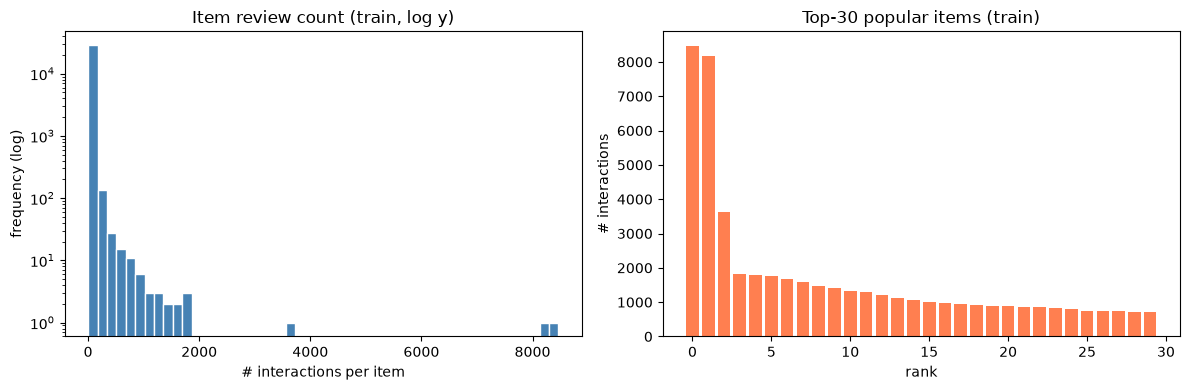

In [15]:
item_train_counts = train["item_id"].value_counts()

print("train item count describe:")
display(item_train_counts.describe())

# 상위 1% / 5% / 10% 아이템이 train 상호작용을 얼마나 먹는지
cum = item_train_counts.sort_values(ascending=False).cumsum() / item_train_counts.sum()
for p in (0.01, 0.05, 0.10):
    n = max(1, int(len(item_train_counts) * p))
    share = cum.iloc[n - 1]
    print(f"top {p:.0%} items (n={n:,}) cover {share:.1%} of train interactions")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(item_train_counts, bins=50, log=True, color="steelblue", edgecolor="white")
axes[0].set_title("Item review count (train, log y)")
axes[0].set_xlabel("# interactions per item")
axes[0].set_ylabel("frequency (log)")

# 상위 30개만 막대
top30 = item_train_counts.head(30)
axes[1].bar(range(len(top30)), top30.values, color="coral")
axes[1].set_title("Top-30 popular items (train)")
axes[1].set_xlabel("rank")
axes[1].set_ylabel("# interactions")

plt.tight_layout()
plt.show()

## Takeaway 메모

- 유저당 상호작용이 매우 적으면(중위수 1) CF / content 시드가 약해질 수 있음
- 롱테일이 심하면 popularity가 오프라인 Recall에서 유리
- cold user 비율이 높으면 `eval_smoke`처럼 warm user만 보는 이유를 README/면접에서 설명할 수 있음
- 다음 코드 읽기: `scripts/prepare_splits.py` → `backend/services/recommend.py`